# Image Compression with KMeans Clustering

### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from PIL import Image

### Load image

In [17]:
image = Image.open("./images/field.jpg")
image = image.resize((512,512))


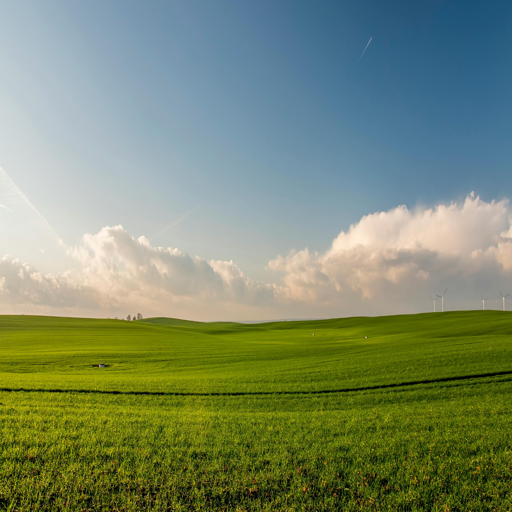

In [18]:
image

In [19]:
image = np.array(image)
print("Shape: ", image.shape)

Shape:  (512, 512, 3)


### Reshape image
Reshape the original image to m where m = number of pixels

In [20]:
image_reshaped = np.reshape(image, (image.shape[0] * image.shape[1], 3))
image_reshaped.shape

(262144, 3)

### Kmeans
Apply kmeans clustering on the image with n_cluster = 16
This will find a unique 16 colors to represent the image

In [21]:
kmeans = KMeans(n_clusters=16, random_state=42)
kmeans.fit(image_reshaped)

KMeans(n_clusters=16, random_state=42)

### Compress the image
Assign each pixel position to its closest centroid using the, and reconstruct the image

In [22]:
new_colors = kmeans.cluster_centers_[kmeans.labels_]
new_colors.shape

(262144, 3)

In [23]:
compressed_img = new_colors.reshape(image.shape).astype(np.uint8)
compressed_img.shape

(512, 512, 3)

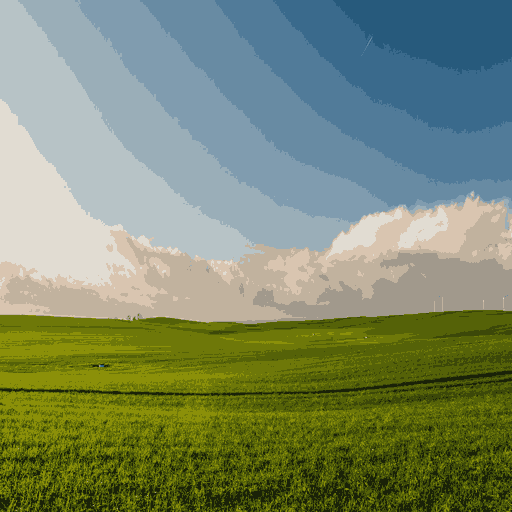

In [24]:
compressed_img = Image.fromarray(compressed_img)
compressed_img

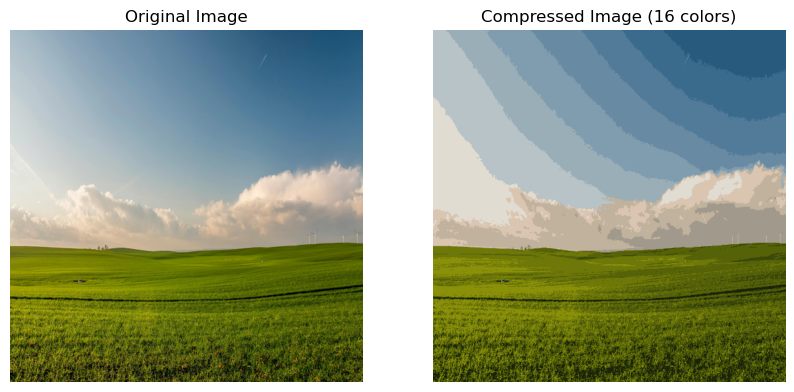

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(compressed_img)
axes[1].set_title(f"Compressed Image ({16} colors)")
axes[1].axis('off')

plt.show()

### Save the image

In [26]:
compressed_img.save("./images/compressed_image.jpg")

### New Color palette

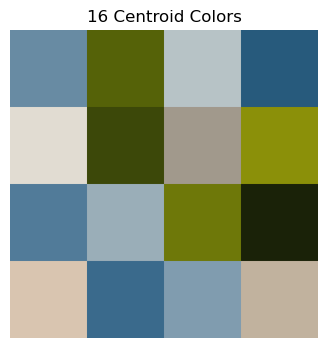

In [27]:
centroids = kmeans.cluster_centers_.astype(np.uint8)
n_colors = centroids.shape[0]

grid_cols = int(np.ceil(np.sqrt(n_colors)))
grid_rows = int(np.ceil(n_colors / grid_cols))

block_size = 100
palette_img = np.zeros((grid_rows * block_size, grid_cols * block_size, 3), dtype=np.uint8)

for i, color in enumerate(centroids):
    row = i // grid_cols
    col = i % grid_cols
    palette_img[
        row * block_size : (row + 1) * block_size,
        col * block_size : (col + 1) * block_size,
    ] = color

plt.figure(figsize=(6, 4))
plt.imshow(palette_img)
plt.axis('off')
plt.title(f"{n_colors} Centroid Colors")
plt.show()